<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/02_classification/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart City Mobility: Predicting Surge Demand (Classification)

**Objective:** Shift from predicting exact bike counts to classifying whether a specific hour will experience "Surge Demand" (High traffic).
**Algorithm:** Logistic Regression (Baseline Classification)

In this notebook, we will:
1. Load and clean the UCI Seoul Bike dataset.
2. **Feature Engineering:** Create a new binary target variable (`Is_Surge`).
3. Preprocess and scale the data.
4. Train a Logistic Regression model to classify demand states.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
df = pd.read_csv(url, encoding='ISO-8859-1')

# Clean column names
df.columns = ['Date', 'Rented_Bike_Count', 'Hour', 'Temperature_C', 'Humidity_pct',
              'Wind_Speed_ms', 'Visibility_10m', 'Dew_Point_C', 'Solar_Radiation_MJm2',
              'Rainfall_mm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']

# Convert Date and extract features
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df = df.drop('Date', axis=1)

print("Data loaded and cleaned successfully!")

Data loaded and cleaned successfully!


## Feature Engineering: Creating the 'Surge' Target
To perform classification, we need categories. We will define **"Surge Demand"** as any hour where the number of rented bikes exceeds 1,000.

We will create a new column called `Is_Surge`:
* **1 (Yes):** Demand > 1000 bikes
* **0 (No):** Demand <= 1000 bikes

After this, we will drop the original `Rented_Bike_Count` column so the model doesn't use the answer to cheat!

In [6]:
# Define the threshold for a surge
surge_threshold = 1000

# Create the new binary target column using numpy's where function
df['Is_Surge'] = np.where(df['Rented_Bike_Count'] > surge_threshold, 1, 0)

# Drop the original continuous variable to prevent data leakage
df_class = df.drop('Rented_Bike_Count', axis=1)

# Check the balance of our new classes
class_counts = df_class['Is_Surge'].value_counts()
print("--- Class Distribution ---")
print(f"Normal Demand (0): {class_counts[0]} hours")
print(f"Surge Demand (1):  {class_counts[1]} hours")

display(df_class.head())

--- Class Distribution ---
Normal Demand (0): 6342 hours
Surge Demand (1):  2418 hours


,Hour,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_10m,Dew_Point_C,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Seasons,Holiday,Functioning_Day,Month,DayOfWeek,Is_Surge
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,4,0


## 3. Visualizing the Classes
Before training, let's see if there is a visible difference between Normal and Surge hours based on weather. We will use a boxplot to compare the temperature distributions for both categories.

/tmp/ipykernel_1062/478766116.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Surge', y='Temperature_C', data=df_class, palette='Set2')


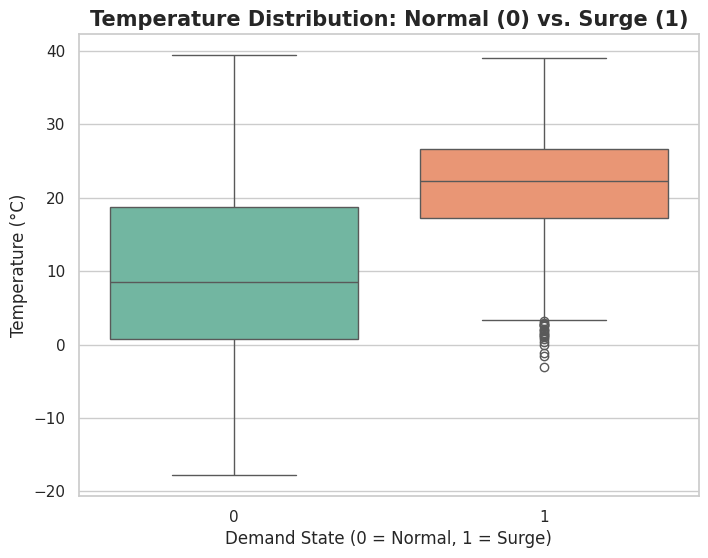

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is_Surge', y='Temperature_C', data=df_class, palette='Set2')

plt.title('Temperature Distribution: Normal (0) vs. Surge (1)', fontsize=15, fontweight='bold')
plt.xlabel('Demand State (0 = Normal, 1 = Surge)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.show()

## Explanation






*   Normal Demand (0 - Green Box): The temperature range for normal hours is massive, stretching all the way from -18°C up to nearly 40°C. The median temperature sits quite low, right around 8°C to 9°C.

*   Surge Demand (1 - Orange Box): The surge box is much tighter and sits significantly higher on the y-axis. The median temperature during a surge is a very comfortable 22°C to 23°C.
*   The Outliers: Notice the little circles at the bottom of the orange Surge box. Those are outliers. It proves that a surge in bike rentals almost never happens when it drops below 5°C.






## 4. Preprocessing for Logistic Regression
Logistic Regression is a linear model, but it wraps the linear equation in a **Sigmoid function** to squash the output into a probability between 0 and 1:
$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \dots + \beta_nx_n)}}$$

Just like Linear Regression, it requires all text to be converted to numbers, and all features to be scaled.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df_class, columns=['Seasons', 'Holiday', 'Functioning_Day'], drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop('Is_Surge', axis=1)
y = df_encoded['Is_Surge']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data encoded, split, and scaled successfully!")

Data encoded, split, and scaled successfully!


## 5. Training the Model
We will train the `LogisticRegression` model. Since our dataset is imbalanced (more normal hours than surge hours), we will use `class_weight='balanced'`. This mathematically forces the algorithm to pay extra attention to the minority class (Surge hours) so it doesn't just lazily predict "Normal" every time.

In [10]:
from sklearn.linear_model import LogisticRegression

# Initialize the model with balanced class weights
log_model = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model successfully trained!")

Logistic Regression model successfully trained!


## 6. Evaluation: The Confusion Matrix
In classification, accuracy isn't enough. We need to see exactly where the model is making mistakes. A Confusion Matrix shows us:
*   **True Positives:** Predicted Surge, and it WAS a Surge.
*   **True Negatives:** Predicted Normal, and it WAS Normal.
*   **False Positives (Type I Error):** Predicted Surge, but it was Normal.
*   **False Negatives (Type II Error):** Predicted Normal, but it was a Surge.

<Figure size 600x600 with 0 Axes>

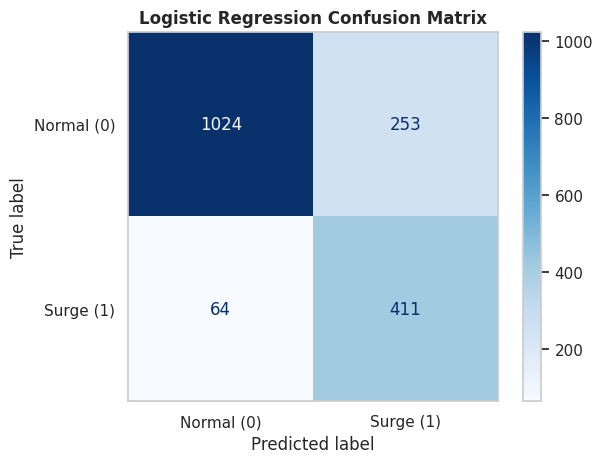


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      1277
           1       0.62      0.87      0.72       475

    accuracy                           0.82      1752
   macro avg       0.78      0.83      0.79      1752
weighted avg       0.85      0.82      0.83      1752



In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred_log = log_model.predict(X_test_scaled)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot the confusion matrix beautifully
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Surge (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression Confusion Matrix', fontweight='bold')
plt.grid(False) # Hides grid lines on the matrix
plt.show()

# Print the detailed classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_log))

## From the Confusion Matrix above:
Top Left (1024 - True Negatives): The model correctly predicted a Normal hour.

Bottom Right (411 - True Positives): The model correctly predicted a Surge hour.

Bottom Left (64 - False Negatives): The model predicted Normal, but it was actually a Surge. (It missed the surge completely).

Top Right (253 - False Positives): The model predicted a Surge, but it was actually a Normal hour. (A false alarm).